# Inflation forecasting with exogenous variables

This notebook benchmarks the public-data Forte (2024) reconstruction with Argentine monthly CPI inflation as the target. Trees and AutoARIMAX issue twelve updated one-month-ahead forecasts. Neural models are fitted once at the block origin and then issue twelve rolling one-month-ahead forecasts with fixed weights and an expanding observed history.

The default `strict_lagged` matrix uses two inflation lags, lag 1 of every available predictor, and lag 2 of activity. It excludes contemporaneous exchange-rate values. `forte_figure4_retrospective` reproduces the paper's 15-feature timing more closely, including contemporaneous official and parallel FX, but must be interpreted as an end-of-month retrospective nowcast rather than a vintage-safe real-time forecast.

Forte re-estimates at every monthly origin from a random 80% subsample, evaluates the remaining 20%, repeats the resampling 25 times, and uses random 10-fold cross-validation for hyperparameters. Our trees reproduce the expanding monthly update frequency while preserving chronology instead of random resampling. AutoARIMAX selects its order once at the beginning of each external stage and then re-estimates that fixed specification monthly. Neural models update their information set at every origin but retain the weights fitted at the beginning of the twelve-month block. Consequently, tree and AutoARIMAX results are closer to Forte's monthly recalibration task than the neural results and are not treated as a compute-matched comparison.

## Model eligibility

- XGBoost Random Forest and LightGBM natively route missing feature values and are used on every profile.
- AutoARIMAX and the NeuralForecast models require complete exogenous matrices and are therefore restricted to the Core 8 long and complete no-NIR profiles.
- The primary neural set is AutoRNN, AutoTFT, AutoNBEATSx, AutoTimesNet, AutoKAN, and AutoTiDE: one recurrent, attention, basis-expansion, convolutional, KAN, and MLP representative. Every candidate is tuned and evaluated at `h=1`. The installed AutoLSTM, AutoGRU, AutoVanillaTransformer, AutoAutoformer, AutoNHITS, and AutoTSMixerx implementations also accept future exogenous inputs and remain optional through `ACTIVE_DL_MODELS`. PatchTST, iTransformer, NLinear, ordinary N-BEATS, and ordinary TSMixer do not expose them in this environment.
- XGBRandomForest and LightGBM use only the AutoStationary target in this replication. The transformer is fitted independently at every inner-validation, external-validation, and test origin; transformed inflation lags are rebuilt, and every forecast is inverted before metrics or plots.
- No imputation is performed. The native-missing experiment retains NaNs and supplies missingness and construction-quality indicators.

Three profiles are retained. Core 8 provides the longest clean history; the later complete panel without net reserves provides more predictors over a shorter sample; and the full public panel tests native missing-value handling over the long period. Net reserves are excluded from the complete panel because their numerical completeness depends on the least defensible blank-liability-as-zero convention. The design is intentionally a history-length versus predictor-breadth trade-off, not a common-sample estimate of the isolated effect of adding variables.

In [1]:
from pathlib import Path
import hashlib
import importlib
import json
import os
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'thesis').exists():
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)
THESIS_DIR = REPO_ROOT / 'thesis'
if str(THESIS_DIR) not in sys.path:
    sys.path.insert(0, str(THESIS_DIR))

import exogenous_evaluation
importlib.reload(exogenous_evaluation)

from exogenous_evaluation import (
    FORTE_PROFILES,
    PRIMARY_EXOGENOUS_DL_MODELS,
    active_features,
    audit_missing_and_zeros,
    build_forte_profile,
    economic_feature_label,
    evaluate_autoarimax,
    evaluate_fixed_exogenous_dl,
    evaluate_tree_model,
    fit_and_eval_frames,
    load_exogenous_dl_search_configs,
    run_rolling_dl_shaptime_subprocess,
    rolling_tree_shap,
    future_exogenous_features,
    prepare_tree_origin,
    split_forte_profile,
    stored_dl_trial_evaluation,
    tune_exogenous_dl_models,
    tune_tree_model,
)
from reporting import (
    dataset_descriptor,
    figure_path,
    publication_latex,
    save_matplotlib_figure,
)
from runtime import CPU_THREADS

try:
    import torch
    if torch.cuda.is_available():
        torch.set_float32_matmul_precision('high')
except ImportError:
    pass

## Run controls

Run validation first. It tunes the three retained profiles (`core8_long`, `full13_complete_no_nir`, and `full_public_native`) and saves their resolved configurations and winners. In a fresh kernel, switch to `test`; the notebook then loads the validation decisions and evaluates the frozen overall winner, the AutoStationary tree winner, AutoARIMAX, and the best DL architecture. The latter two are retained so the method-level forecast plot is available; test errors cannot revise any selection.

In [2]:
SEED = 67
EVALUATION_SPLIT = 'validation'  # validation first, then test in a fresh kernel
FEATURE_MODE = 'strict_lagged'
ACTIVE_PROFILES = list(FORTE_PROFILES)

VALIDATION_SIZE = 12
TEST_SIZE = 12
INNER_FOLD_SIZE = 12
TREE_N_TRIALS = 25
TREE_N_SPLITS = 3
TREE_N_JOBS = CPU_THREADS
TREE_MODELS = ('XGBRandomForest', 'LightGBM')
TREE_TARGET_TRANSFORMATIONS = ['AutoStationary']
DL_NUM_SAMPLES = 8
DL_STARTUP_TRIALS = 3
DL_INPUT_SIZE_CANDIDATES = [12, 24, 36, 48]
ACTIVE_DL_MODELS = list(PRIMARY_EXOGENOUS_DL_MODELS)

RUN_TREE_MODELS = True
RUN_AUTOARIMAX = True
RUN_DL_MODELS = True
RUN_INTERPRETABILITY = True
RUN_SHAP = True
REUSE_SHAP_CHECKPOINTS = False
SHAP_BACKGROUND_SIZE = 100
RUN_DL_SHAPTIME = True  # isolated rolling h=1 temporal attribution
SAVE_FIGURES = True
FIGURE_FORMAT = 'jpg'
SHAPTIME_SUPER_TIMES = 4
SHAPTIME_SEASONAL_BACKGROUND_LAG = 12
REUSE_SAVED_VALIDATION_CONFIGS = True
FORECAST_HORIZON = 12
DL_HORIZON = 1
DL_N_WINDOWS = 12
DL_PROTOCOL = 'rolling_h1_fixed_weights'
TREE_RECALIBRATE_EACH_ORIGIN = True
AUTOARIMAX_RECALIBRATE_EACH_ORIGIN = True
DL_RECALIBRATE_EACH_ORIGIN = False

# Disabled by default. To run a tree-only sensitivity, provide explicit
# multipliers such as {'q_pre_comparable_brent_lag1': 0.5}. Metrics remain
# unweighted. AutoARIMAX and NeuralForecast do not receive these weights.
QUALITY_WEIGHT_MULTIPLIERS = {}

CONFIG_PATH = THESIS_DIR / 'model_configs' / 'exogenous_validation_configs.json'
METRICS_DIR = THESIS_DIR / 'metrics'
RESULTS_DIR = THESIS_DIR / 'results'
METRICS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if EVALUATION_SPLIT not in {'validation', 'test'}:
    raise ValueError("EVALUATION_SPLIT must be 'validation' or 'test'")
if VALIDATION_SIZE != FORECAST_HORIZON or TEST_SIZE != FORECAST_HORIZON:
    raise ValueError('Validation and test blocks must equal FORECAST_HORIZON')
if DL_HORIZON != 1 or DL_N_WINDOWS != 12 or DL_RECALIBRATE_EACH_ORIGIN:
    raise ValueError('DL requires one fixed fit and twelve rolling h=1 origins')
if FEATURE_MODE != 'strict_lagged':
    raise ValueError('The canonical exogenous run requires strict_lagged features')
unknown = set(ACTIVE_PROFILES) - set(FORTE_PROFILES)
if unknown:
    raise ValueError(f'Unknown profiles: {sorted(unknown)}')

tree_anchors = sum(
    name == FORTE_PROFILES[name]['tuning_group'] for name in ACTIVE_PROFILES
)
complete_profiles = sum(
    not FORTE_PROFILES[name]['native_missing_only'] for name in ACTIVE_PROFILES
)
print(
    'Hybrid external protocol:\n'
    f'  tree inner rolling fits: {tree_anchors * len(TREE_TARGET_TRANSFORMATIONS) * len(TREE_MODELS) * TREE_N_TRIALS * TREE_N_SPLITS * INNER_FOLD_SIZE:,}\n'
    f'  tree external rolling fits: {len(ACTIVE_PROFILES) * len(TREE_TARGET_TRANSFORMATIONS) * len(TREE_MODELS) * FORECAST_HORIZON:,}\n'
    f'  AutoARIMAX order selections: {complete_profiles:,}; fixed-order monthly refits: {complete_profiles * FORECAST_HORIZON:,}\n'
    f'  neural Optuna fits: {complete_profiles * len(ACTIVE_DL_MODELS) * DL_NUM_SAMPLES:,}; '
    f'{DL_N_WINDOWS} one-step predictions per fit'
)

Hybrid external protocol:
  tree inner rolling fits: 5,400
  tree external rolling fits: 72
  AutoARIMAX order selections: 2; fixed-order monthly refits: 24
  neural Optuna fits: 96; 12 one-step predictions per fit


## Missing-value and suspicious-zero audit

Exact zero is not a universal missing-value code. Zero growth can be genuine, and the zero FX gap is explicitly imposed during documented unified-market regimes. U04 is different: its 1982-07–1984-05 zero block is surrounded by very high positive nominal rates, so only that variable's exact zeros are recoded to NaN by the profile builder.

In [3]:
zero_missing_audit = audit_missing_and_zeros()
display(zero_missing_audit)

u04_audit = zero_missing_audit.loc[
    zero_missing_audit['Variable'].eq('u04_nominal_interest_tem_pct')
].iloc[0]
assert int(u04_audit['Exact Zeros']) == 23
assert u04_audit['First Zero'] == '1982-07-01'
assert u04_audit['Last Zero'] == '1984-05-01'

,Variable,Missing,Exact Zeros,First Zero,Last Zero,Minimum,Maximum
0,u01_arg_cpi_inflation_mom_pct,0,1,2004-11-01,2004-11-01,-5.720442,196.633866
1,u02_registered_wage_growth_mom_pct,1,137,1965-03-01,1994-06-01,-3.175561,218.171536
2,u03_activity_growth_3mma_pct,30,0,None,None,-21.109747,52.183385
3,u04_nominal_interest_tem_pct,3,23,1982-07-01,1984-05-01,0.000000,135.360000
4,u05_monetary_base_growth_mom_pct,0,1,1967-08-01,1967-08-01,-27.013547,392.613392
5,u06_m2_growth_mom_pct,0,0,None,None,-11.079537,103.592310
6,u07_wheat_price_growth_mom_pct,0,38,1965-11-01,2023-07-01,-19.688769,67.975567
7,u08_brent_price_growth_mom_pct,0,146,1965-02-01,2012-12-01,-40.000000,217.073171
8,u09_us_cpi_inflation_mom_pct,0,39,1965-01-01,2002-11-01,-1.915290,1.805869
9,u10_official_fx_growth_mom_pct,0,140,1965-05-01,1998-05-01,-7.071923,320.954897


## Profile and split audit

Every profile uses the same final validation and test months. Only fitting history and predictor availability differ. Missingness indicators are created before constant-feature filtering; preprocessing decisions are made from the current fitting sample only.

In [4]:
prepared_profiles = {}
profile_audit_rows = []

for profile_name in ACTIVE_PROFILES:
    frame, config = build_forte_profile(profile_name, feature_mode=FEATURE_MODE)
    splits = split_forte_profile(frame, VALIDATION_SIZE, TEST_SIZE)
    fit_df, eval_df = fit_and_eval_frames(splits, EVALUATION_SPLIT)
    features = active_features(fit_df, config['feature_columns'])
    future_features = future_exogenous_features(features, FEATURE_MODE)
    prepared_profiles[profile_name] = {
        'frame': frame,
        'config': config,
        'splits': splits,
        'fit_df': fit_df,
        'eval_df': eval_df,
        'candidate_features': list(config['feature_columns']),
        'features': features,
        'future_features': future_features,
    }
    profile_audit_rows.append({
        'Profile': profile_name,
        'Label': config['label'],
        'Tuning group': config['tuning_group'],
        'Rows': len(frame),
        'Fit rows': len(fit_df),
        'Evaluation rows': len(eval_df),
        'Active features': len(features),
        'Future exogenous features': len(future_features),
        'Feature NaNs': int(frame[features].isna().sum().sum()),
        'Native-missing models only': config['native_missing_only'],
        'First month': frame['date'].min().date(),
        'Last month': frame['date'].max().date(),
    })

profile_audit = pd.DataFrame(profile_audit_rows)
display(profile_audit)

,Profile,Label,Tuning group,Rows,Fit rows,Evaluation rows,Active features,Future exogenous features,Feature NaNs,Native-missing models only,First month,Last month
0,core8_long,Core 8 long sample,core8_long,712,688,12,14,12,0,False,1965-04-01,2024-07-01
1,full13_complete_no_nir,Full 13 complete sample without NIR,full13_complete_no_nir,294,270,12,16,14,0,False,2000-02-01,2024-07-01
2,full_public_native,Full public panel with native missing values,full_public_native,713,689,12,28,26,576,True,1965-03-01,2024-07-01


## Configuration loading and restartable tuning

The existing tree search ranges are retained as priors, but tuning is rerun because adding exogenous variables changes the optimization problem. To match Forte's accuracy criterion for this replication, tree holdouts, neural training/validation, external model selection, and interpretation all use MAE; MSE and RMSE remain reported diagnostics. LightGBM also fits with L1 loss. XGBRandomForest must retain its squared-error tree objective because its installed parallel-tree implementation rejects `reg:absoluteerror`, but its hyperparameters and winner status are still selected by MAE.

The inner procedures are intentionally not identical. Trees use expanding-window Rep-Holdout-O with three non-overlapping 12-month blocks, each evaluated as twelve updated one-step origins. Neural Auto models use the last 12 fitting observations as one contiguous temporal holdout for Optuna and early stopping and are tuned directly at horizon 12. Externally, trees and fixed-order AutoARIMAX update monthly, whereas neural models retain one joint block-origin fit.

Tree and neural tuning are separated below. Every completed candidate is written immediately to the JSON checkpoint. Rerunning either cell skips completed candidates and retries only missing or failed ones. Horizon 12 permits the ordinary N-BEATSx basis search; the identity-stack workaround required only by the former one-step experiment is not applied.

In [5]:
def json_default(value):
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    raise TypeError(f'Cannot serialize {type(value).__name__}')


current_protocol = {
    'seed': SEED,
    'active_profiles': ACTIVE_PROFILES,
    'feature_mode': FEATURE_MODE,
    'validation_size': VALIDATION_SIZE,
    'test_size': TEST_SIZE,
    'forecast_horizon': FORECAST_HORIZON,
    'inner_fold_size': INNER_FOLD_SIZE,
    'optimization_metric': 'mae',
    'tree_recalibrate_each_origin': TREE_RECALIBRATE_EACH_ORIGIN,
    'autoarimax_recalibrate_each_origin': AUTOARIMAX_RECALIBRATE_EACH_ORIGIN,
    'dl_recalibrate_each_origin': DL_RECALIBRATE_EACH_ORIGIN,
    # Legacy value retained only to keep the established checkpoint path.
    # Corrected neural candidates record DL_PROTOCOL inside this same file.
    'external_strategy': 'rolling_trees_arimax_joint_dl',
    'tree_trials': TREE_N_TRIALS,
    'tree_splits': TREE_N_SPLITS,
    'tree_models': list(TREE_MODELS),
    'tree_target_transformations': TREE_TARGET_TRANSFORMATIONS,
    'dl_samples': DL_NUM_SAMPLES,
    'dl_startup_trials': DL_STARTUP_TRIALS,
    'dl_input_size_candidates': DL_INPUT_SIZE_CANDIDATES,
    'active_dl_models': ACTIVE_DL_MODELS,
    'quality_weight_multipliers': QUALITY_WEIGHT_MULTIPLIERS,
}


def empty_config_store():
    return {
        'protocol': current_protocol,
        'tree': {},
        'dl': {},
        'dl_timing': {},
        'dl_shortlist': [],
        'winners': {},
        'tree_winners': {},
        'best_tree': {},
        'best_dl': {},
    }


def protocol_mismatches(store):
    saved_protocol = store.get('protocol', {})
    return {
        key: (saved_protocol.get(key), value)
        for key, value in current_protocol.items()
        if saved_protocol.get(key) != value
    }


def persist_config_store():
    CONFIG_PATH.write_text(
        json.dumps(config_store, indent=2, default=json_default),
        encoding='utf-8',
    )


# Preserve work already completed in the active kernel. Otherwise load the
# candidate-level disk checkpoint. This also recovers cleanly after a restart.
if 'config_store' in globals():
    mismatches = protocol_mismatches(config_store)
elif CONFIG_PATH.exists() and (
    EVALUATION_SPLIT == 'test' or REUSE_SAVED_VALIDATION_CONFIGS
):
    config_store = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))
    mismatches = protocol_mismatches(config_store)
else:
    config_store = empty_config_store()
    mismatches = {}

completed_config_sections = ('tree', 'dl', 'winners', 'tree_winners', 'best_dl')
checkpoint_has_results = any(config_store.get(key) for key in completed_config_sections)
if mismatches and EVALUATION_SPLIT == 'validation' and not checkpoint_has_results:
    print('Replacing an empty configuration checkpoint with the current protocol.')
    config_store = empty_config_store()
    mismatches = {}
if mismatches:
    raise ValueError(
        f'Saved exogenous configs use a different protocol: {mismatches}. '
        'Use a new CONFIG_PATH or explicitly replace the old validation file.'
    )

for key, default in empty_config_store().items():
    config_store.setdefault(key, default)
config_store['protocol'] = current_protocol

if EVALUATION_SPLIT == 'test' and not CONFIG_PATH.exists():
    raise FileNotFoundError('Run validation first to create frozen configurations')
if EVALUATION_SPLIT == 'test':
    invalid_tree_configs = [
        (group, target, model)
        for group, targets in config_store.get('tree', {}).items()
        for target, models in targets.items()
        for model, record in models.items()
        if record.get('feature_eligibility') != 'origin_fit'
    ]
    if invalid_tree_configs:
        raise ValueError(
            'Tree configurations predate nested feature eligibility; '
            'run validation first.'
        )
    if RUN_DL_MODELS:
        shortlist = config_store.get('dl_shortlist', [])
        required_shortlist_fields = {
            'profile', 'architecture', 'resolved_config',
            'validation_mae', 'candidate_id',
        }
        if (
            len(shortlist) != 2
            or any(
                not required_shortlist_fields.issubset(candidate)
                for candidate in shortlist
            )
        ):
            raise ValueError(
                'The corrected two-model neural shortlist is missing; '
                'run validation first.'
            )
if EVALUATION_SPLIT == 'validation':
    persist_config_store()

print(f'Configuration checkpoint: {CONFIG_PATH}')

Configuration checkpoint: c:\Users\tutol\Desktop\Repos\Modern-Time-Series-Forecasting-with-Python-2E\thesis\model_configs\exogenous_validation_configs.json


### Tree hyperparameter tuning

XGBRandomForest and LightGBM are tuned only on the AutoStationary target. Each completed candidate is checkpointed immediately.

In [6]:
tree_tuning_failures = []

if EVALUATION_SPLIT == 'validation' and RUN_TREE_MODELS:
    for profile_name in ACTIVE_PROFILES:
        data = prepared_profiles[profile_name]
        group = data['config']['tuning_group']
        if profile_name != group:
            continue
        print(f'Tree configuration anchor: {profile_name}')
        tuning_features = list(data['candidate_features'])
        group_store = config_store['tree'].setdefault(group, {})
        for target_transformation in TREE_TARGET_TRANSFORMATIONS:
            representation_store = group_store.setdefault(
                target_transformation, {}
            )
            for model_name in TREE_MODELS:
                existing = representation_store.get(model_name, {})
                if existing.get('feature_eligibility') == 'origin_fit':
                    print(f'  reusing {model_name} - {target_transformation}')
                    continue
                representation_store.pop(model_name, None)
                persist_config_store()
                print(f'  tuning {model_name} - {target_transformation}')
                try:
                    representation_store[model_name] = tune_tree_model(
                        data['splits']['train'],
                        tuning_features,
                        model_name,
                        n_trials=TREE_N_TRIALS,
                        n_splits=TREE_N_SPLITS,
                        fold_size=INNER_FOLD_SIZE,
                        seed=SEED,
                        n_jobs=TREE_N_JOBS,
                        weight_multipliers=QUALITY_WEIGHT_MULTIPLIERS,
                        recalibrate_each_origin=TREE_RECALIBRATE_EACH_ORIGIN,
                        target_transformation=target_transformation,
                        feature_mode=FEATURE_MODE,
                        freq='MS',
                    )
                    persist_config_store()
                except Exception as error:
                    tree_tuning_failures.append({
                        'Profile': profile_name,
                        'Target': target_transformation,
                        'Model': model_name,
                        'Error': f'{type(error).__name__}: {error}',
                    })
                    print(
                        f'  {model_name} - {target_transformation} failed; '
                        'completed candidates remain checkpointed.'
                    )

display(pd.DataFrame(tree_tuning_failures))

""


### Deep-learning hyperparameter tuning

Each architecture is tuned separately and checkpointed before the next begins. A normal model exception is recorded and does not stop later architectures. After correcting a failed architecture, rerun only this cell: completed configurations are reused.

In [7]:
dl_tuning_failures = []

if EVALUATION_SPLIT == 'validation' and RUN_DL_MODELS:
    for profile_name in ACTIVE_PROFILES:
        data = prepared_profiles[profile_name]
        group = data['config']['tuning_group']
        if profile_name != group or data['config']['native_missing_only']:
            continue
        print(f'DL configuration anchor: {profile_name}')
        # With rolling h=1, target lags are known at the origin and remain
        # part of the existing strict-lagged neural feature profile.
        tuning_features = active_features(
            data['splits']['train'], data['config']['feature_columns']
        )
        search_configs = load_exogenous_dl_search_configs(
            tuning_features,
            input_size_candidates=DL_INPUT_SIZE_CANDIDATES,
            num_samples=DL_NUM_SAMPLES,
            startup_trials=DL_STARTUP_TRIALS,
            active_models=ACTIVE_DL_MODELS,
            forecast_horizon=DL_HORIZON,
        )
        resolved_store = config_store['dl'].setdefault(group, {})
        timing_records = config_store['dl_timing'].setdefault(group, [])
        for model_name, search_config in search_configs.items():
            existing = resolved_store.get(model_name, {})
            if (
                existing.get('_dl_protocol') == DL_PROTOCOL
                and len(existing.get('_trial_records', [])) == DL_NUM_SAMPLES
            ):
                print(f'  reusing {model_name}')
                continue
            resolved_store.pop(model_name, None)
            persist_config_store()
            try:
                resolved, timing = tune_exogenous_dl_models(
                    data['splits']['train'],
                    data['splits']['validation'],
                    tuning_features,
                    {model_name: search_config},
                    progress_label=profile_name,
                    forecast_horizon=DL_HORIZON,
                )
                resolved_store.update(resolved)
                timing_records[:] = [
                    row for row in timing_records
                    if row['Model'] != model_name
                ]
                timing_records.extend(timing.to_dict(orient='records'))
                persist_config_store()
            except Exception as error:
                dl_tuning_failures.append({
                    'Profile': profile_name,
                    'Model': model_name,
                    'Error': f'{type(error).__name__}: {error}',
                })
                print(
                    f'  {model_name} failed; completed architectures remain '
                    'checkpointed and later architectures will continue.'
                )

    completed_trials = []
    for group, architecture_configs in config_store['dl'].items():
        for architecture, best_config in architecture_configs.items():
            records = best_config.get('_trial_records', [])
            for record in records:
                candidate = dict(record)
                candidate['profile'] = group
                candidate['architecture'] = architecture
                completed_trials.append(candidate)
    expected_trials = complete_profiles * len(ACTIVE_DL_MODELS) * DL_NUM_SAMPLES
    if len(completed_trials) == expected_trials:
        shortlist = sorted(
            completed_trials, key=lambda row: float(row['validation_mae'])
        )[:2]
        seen_architectures = set()
        for candidate in shortlist:
            architecture_key = (
                candidate['profile'], candidate['architecture']
            )
            if architecture_key in seen_architectures:
                candidate['candidate_id'] = (
                    f"{candidate['architecture']} (trial "
                    f"{candidate['trial_number']})"
                )
                candidate['checkpoint_model_name'] = None
            else:
                candidate['candidate_id'] = candidate['architecture']
                candidate['checkpoint_model_name'] = candidate['architecture']
                seen_architectures.add(architecture_key)
        config_store['dl_shortlist'] = shortlist
        persist_config_store()
        print('Frozen neural shortlist:', [
            (row['profile'], row['candidate_id'], row['validation_mae'])
            for row in config_store['dl_shortlist']
        ])

dl_tuning_status = pd.DataFrame([
    {
        'Tuning Group': group,
        'Model': model_name,
        'Completed': (
            config_store['dl'].get(group, {}).get(model_name, {}).get(
                '_dl_protocol'
            ) == DL_PROTOCOL
            and len(config_store['dl'].get(group, {}).get(
                model_name, {}
            ).get('_trial_records', [])) == DL_NUM_SAMPLES
        ),
    }
    for group in {
        FORTE_PROFILES[name]['tuning_group'] for name in ACTIVE_PROFILES
        if not FORTE_PROFILES[name]['native_missing_only']
    }
    for model_name in ACTIVE_DL_MODELS
])
display(dl_tuning_status)
display(pd.DataFrame(dl_tuning_failures))

,Tuning Group,Model,Completed
0,full13_complete_no_nir,AutoRNN,True
1,full13_complete_no_nir,AutoTFT,True
2,full13_complete_no_nir,AutoNBEATSx,True
3,full13_complete_no_nir,AutoTimesNet,True
4,full13_complete_no_nir,AutoKAN,True
5,full13_complete_no_nir,AutoTiDE,True
6,core8_long,AutoRNN,True
7,core8_long,AutoTFT,True
8,core8_long,AutoNBEATSx,True
9,core8_long,AutoTimesNet,True


""


## External validation or final test

The external block contains twelve monthly origins for trees, AutoARIMAX, and neural models. Trees are refitted on the expanding history before every one-step prediction. AutoARIMAX performs one automatic order search at the beginning of the stage, freezes that order, and re-estimates its coefficients monthly as observations are revealed. Each neural candidate is fitted once at the block origin; its weights remain fixed while the observed history is updated before each of twelve one-step predictions. Validation evaluates every enabled candidate. Test retains the two neural architecture, configuration, and profile combinations shortlisted by validation; the native-missing profile additionally retains both eligible trees for plotting while still highlighting only its validation winner. Test cannot replace any validation-selected identity.

Tree, AutoARIMAX, and DL evaluation are separate below. Successful model outputs are checkpointed by protocol and candidate, so rerunning after a kernel restart skips completed forecasts and retries failures.

In [6]:
protocol_digest = hashlib.sha256(
    json.dumps(current_protocol, sort_keys=True, default=json_default).encode()
).hexdigest()[:12]
EVALUATION_CHECKPOINT_DIR = (
    METRICS_DIR / 'exogenous_checkpoints'
    / f'{EVALUATION_SPLIT}_{protocol_digest}'
)
EVALUATION_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


def evaluation_checkpoint_paths(method, profile_name, model_name):
    stem = '__'.join((method, profile_name, model_name)).replace('/', '_')
    return (
        EVALUATION_CHECKPOINT_DIR / f'{stem}_forecast.csv',
        EVALUATION_CHECKPOINT_DIR / f'{stem}_metric.json',
    )


def save_evaluation_checkpoint(method, profile_name, model_name, results, metric):
    forecast_path, metric_path = evaluation_checkpoint_paths(
        method, profile_name, model_name,
    )
    results.to_csv(forecast_path, index=False)
    metric_path.write_text(
        json.dumps(metric, indent=2, default=json_default), encoding='utf-8',
    )


def load_evaluation_checkpoint(
    method, profile_name, model_name, expected_trial_number=None,
):
    forecast_path, metric_path = evaluation_checkpoint_paths(
        method, profile_name, model_name,
    )
    if not (forecast_path.exists() and metric_path.exists()):
        return None
    results = pd.read_csv(forecast_path, parse_dates=['date'])
    metric = json.loads(metric_path.read_text(encoding='utf-8'))
    if method == 'dl' and metric.get('DL Protocol') != DL_PROTOCOL:
        return None
    if (
        method == 'dl' and expected_trial_number is not None
        and metric.get('DL Trial Number') != int(expected_trial_number)
    ):
        return None
    if method == 'tree' and metric.get('Feature Eligibility') != 'origin_fit':
        return None
    return results, metric


evaluation_state_key = (
    EVALUATION_SPLIT,
    FEATURE_MODE,
    tuple(ACTIVE_PROFILES),
    TREE_RECALIBRATE_EACH_ORIGIN,
    AUTOARIMAX_RECALIBRATE_EACH_ORIGIN,
    DL_RECALIBRATE_EACH_ORIGIN,
)
if globals().get('_exogenous_evaluation_state_key') != evaluation_state_key:
    methodology_results = {
        'tree': {},
        'autoarimax': {},
        'dl': {},
    }
    methodology_metrics = {
        'tree': {},
        'autoarimax': {},
        'dl': {},
    }
    fitted_trees = {}
    _exogenous_evaluation_state_key = evaluation_state_key


def selected_models_for_profile(profile_name):
    if EVALUATION_SPLIT == 'validation':
        return None
    if profile_name not in config_store['winners']:
        raise KeyError(
            f'{profile_name}: validation winners are missing from {CONFIG_PATH}'
        )
    selected = {config_store['winners'][profile_name]['model']}
    selected.update(
        choice['model']
        for choice in config_store['tree_winners'][profile_name].values()
    )
    selected.update(
        record['candidate_id']
        for record in config_store.get('dl_shortlist', [])
        if record['profile'] == profile_name
    )
    if FORTE_PROFILES[profile_name]['native_missing_only']:
        selected.update(
            model if target == 'Original' else f'{model}_AutoStationary'
            for target in TREE_TARGET_TRANSFORMATIONS
            for model in TREE_MODELS
        )
    if not FORTE_PROFILES[profile_name]['native_missing_only']:
        selected.add('AutoARIMAX')
    return selected


for method in methodology_results:
    for profile_name in ACTIVE_PROFILES:
        methodology_results[method].setdefault(profile_name, {})
        methodology_metrics[method].setdefault(profile_name, {})
fitted_trees = {
    profile_name: fitted_trees.get(profile_name, {})
    for profile_name in ACTIVE_PROFILES
}

print('Methodology-specific evaluation state initialized.')

Methodology-specific evaluation state initialized.


### Tree-model rolling monthly evaluation

Rerunning this cell evaluates only tree candidates not already completed in the active evaluation state.

In [9]:
tree_evaluation_failures = []
tree_evaluation_start = time.perf_counter()

if RUN_TREE_MODELS:
    for profile_index, profile_name in enumerate(ACTIVE_PROFILES, start=1):
        data = prepared_profiles[profile_name]
        group = data['config']['tuning_group']
        selected_models = selected_models_for_profile(profile_name)
        print(f'[tree {profile_index}/{len(ACTIVE_PROFILES)}] {profile_name}')
        for target_transformation in TREE_TARGET_TRANSFORMATIONS:
            for model_name in TREE_MODELS:
                output_name = (
                    model_name
                    if target_transformation == 'Original'
                    else f'{model_name}_AutoStationary'
                )
                if selected_models is not None and output_name not in selected_models:
                    continue
                cached = load_evaluation_checkpoint(
                    'tree', profile_name, output_name,
                )
                if cached is not None:
                    model_results, metric = cached
                    methodology_results['tree'][profile_name][output_name] = model_results
                    methodology_metrics['tree'][profile_name][output_name] = metric
                    print(f'  reusing checkpointed {output_name}')
                    continue
                if output_name in methodology_metrics['tree'][profile_name]:
                    print(f'  reusing {output_name}')
                    continue
                print(f'  evaluating {output_name}')
                try:
                    config = config_store['tree'][group][
                        target_transformation
                    ][model_name]
                    model_results, metric, fitted = evaluate_tree_model(
                        data['fit_df'],
                        data['eval_df'],
                        data['candidate_features'],
                        config,
                        n_jobs=TREE_N_JOBS,
                        weight_multipliers=QUALITY_WEIGHT_MULTIPLIERS,
                        recalibrate_each_origin=TREE_RECALIBRATE_EACH_ORIGIN,
                        feature_mode=FEATURE_MODE,
                        freq='MS',
                    )
                    methodology_results['tree'][profile_name][
                        output_name
                    ] = model_results
                    methodology_metrics['tree'][profile_name][
                        output_name
                    ] = metric
                    fitted_trees[profile_name][output_name] = fitted
                    save_evaluation_checkpoint(
                        'tree', profile_name, output_name, model_results, metric,
                    )
                except Exception as error:
                    tree_evaluation_failures.append({
                        'Profile': profile_name,
                        'Model': output_name,
                        'Error': f'{type(error).__name__}: {error}',
                    })
                    print(f'  {output_name} failed and remains retryable.')

print(
    'Tree evaluation cell time: '
    f'{(time.perf_counter() - tree_evaluation_start) / 60:.1f} minutes'
)
display(pd.DataFrame(tree_evaluation_failures))

[tree 1/3] core8_long
  evaluating LightGBM_AutoStationary
[tree 2/3] full13_complete_no_nir
  evaluating LightGBM_AutoStationary
[tree 3/3] full_public_native
  evaluating XGBRandomForest_AutoStationary
  evaluating LightGBM_AutoStationary
Tree evaluation cell time: 0.3 minutes


""


### AutoARIMAX fixed-order rolling evaluation

AutoARIMAX is evaluated only on complete-data profiles. It performs the expensive order search once at the beginning of the stage, then holds that order fixed while re-estimating coefficients and state on each expanding monthly history. The updates remain relevant because newly observed inflation, regressors, and residuals change the fitted coefficients and terminal state. This cell is independent of both tree and neural evaluation.

In [10]:
autoarimax_evaluation_failures = []
autoarimax_start = time.perf_counter()

if RUN_AUTOARIMAX:
    for profile_name in ACTIVE_PROFILES:
        data = prepared_profiles[profile_name]
        if data['config']['native_missing_only']:
            continue
        selected_models = selected_models_for_profile(profile_name)
        if selected_models is not None and 'AutoARIMAX' not in selected_models:
            continue
        cached = load_evaluation_checkpoint(
            'autoarimax', profile_name, 'AutoARIMAX',
        )
        if cached is not None:
            model_results, metric = cached
            methodology_results['autoarimax'][profile_name]['AutoARIMAX'] = model_results
            methodology_metrics['autoarimax'][profile_name]['AutoARIMAX'] = metric
            print(f'{profile_name}: reusing checkpointed AutoARIMAX')
            continue
        if 'AutoARIMAX' in methodology_metrics['autoarimax'][profile_name]:
            print(f'{profile_name}: reusing AutoARIMAX')
            continue
        print(f'{profile_name}: evaluating AutoARIMAX')
        try:
            model_results, metric = evaluate_autoarimax(
                data['fit_df'],
                data['eval_df'],
                data['future_features'],
                recalibrate_each_origin=AUTOARIMAX_RECALIBRATE_EACH_ORIGIN,
            )
            methodology_results['autoarimax'][profile_name][
                'AutoARIMAX'
            ] = model_results
            methodology_metrics['autoarimax'][profile_name][
                'AutoARIMAX'
            ] = metric
            save_evaluation_checkpoint(
                'autoarimax', profile_name, 'AutoARIMAX', model_results, metric,
            )
        except Exception as error:
            autoarimax_evaluation_failures.append({
                'Profile': profile_name,
                'Model': 'AutoARIMAX',
                'Error': f'{type(error).__name__}: {error}',
            })
            print(f'{profile_name}: AutoARIMAX failed and remains retryable.')

print(
    'AutoARIMAX evaluation cell time: '
    f'{(time.perf_counter() - autoarimax_start) / 60:.1f} minutes'
)
display(pd.DataFrame(autoarimax_evaluation_failures))

core8_long: reusing checkpointed AutoARIMAX
full13_complete_no_nir: reusing checkpointed AutoARIMAX
AutoARIMAX evaluation cell time: 0.0 minutes


""


### Deep-learning 12-month evaluation

Each resolved architecture is evaluated independently. A failed architecture is recorded while later architectures continue; rerunning this cell skips successful evaluations.

In [11]:
dl_evaluation_failures = []
dl_evaluation_start = time.perf_counter()

if RUN_DL_MODELS:
    shortlist = config_store.get('dl_shortlist', [])
    if len(shortlist) != 2:
        raise RuntimeError(
            'The two validation-shortlisted neural configurations are missing; '
            'run the validation search cell first.'
        )
    assert EVALUATION_SPLIT in {'validation', 'test'}
    for candidate in shortlist:
        profile_name = candidate['profile']
        if profile_name not in ACTIVE_PROFILES:
            continue
        data = prepared_profiles[profile_name]
        model_name = candidate['architecture']
        output_name = candidate['candidate_id']
        checkpoint_name = candidate.get('checkpoint_model_name')
        cached = (
            load_evaluation_checkpoint(
                'dl', profile_name, checkpoint_name,
                expected_trial_number=candidate['trial_number'],
            )
            if checkpoint_name else None
        )
        if cached is not None:
            model_results, metric = cached
            methodology_results['dl'][profile_name][output_name] = model_results
            methodology_metrics['dl'][profile_name][output_name] = metric
            print(f'{profile_name}: reusing checkpointed {output_name}')
            continue
        if output_name in methodology_metrics['dl'][profile_name]:
            print(f'{profile_name}: reusing {output_name}')
            continue
        print(f'{profile_name}: evaluating {output_name}')
        try:
            if EVALUATION_SPLIT == 'validation':
                timing_lookup = {
                    row['Model']: row['Tuning Time']
                    for row in config_store['dl_timing'].get(profile_name, [])
                }
                model_results, metric = stored_dl_trial_evaluation(
                    candidate,
                    tuning_time=float(timing_lookup.get(model_name, 0.0)),
                )
            else:
                # Test never calls the Optuna search; this is one fixed fit.
                model_results, metric = evaluate_fixed_exogenous_dl(
                    data['fit_df'],
                    data['eval_df'],
                    data['features'],
                    model_name,
                    candidate['resolved_config'],
                    tuning_time=0.0,
                    recalibrate_each_origin=False,
                    output_name=output_name,
                    feature_mode=FEATURE_MODE,
                )
            assert len(model_results) == 12
            assert model_results['date'].nunique() == 12
            assert int(metric['Fits']) == 1
            metric['DL Trial Number'] = int(candidate['trial_number'])
            metric['DL Validation MAE'] = float(candidate['validation_mae'])
            methodology_results['dl'][profile_name][output_name] = model_results
            methodology_metrics['dl'][profile_name][output_name] = metric
            if checkpoint_name:
                save_evaluation_checkpoint(
                    'dl', profile_name, checkpoint_name, model_results, metric,
                )
        except Exception as error:
            dl_evaluation_failures.append({
                'Profile': profile_name,
                'Model': output_name,
                'Error': f'{type(error).__name__}: {error}',
            })
            print(
                f'{profile_name}: {output_name} failed and remains retryable.'
            )

print(
    'DL evaluation cell time: '
    f'{(time.perf_counter() - dl_evaluation_start) / 60:.1f} minutes'
)
display(pd.DataFrame(dl_evaluation_failures))

full13_complete_no_nir: evaluating AutoTimesNet


Seed set to 67
Seed set to 67


core8_long: evaluating AutoTimesNet
DL evaluation cell time: 1.6 minutes


""


### Combine methodology outputs

This inexpensive cell merges the completed methodology-specific forecasts and metrics. It can be rerun freely after retrying any failed method.

In [9]:
all_metrics = []
all_results = {}

for profile_name in ACTIVE_PROFILES:
    data = prepared_profiles[profile_name]
    results = data['eval_df'][['date', 'y']].copy()
    profile_metric_rows = []
    for method in ('tree', 'autoarimax', 'dl'):
        for model_name, model_results in methodology_results[method][
            profile_name
        ].items():
            results = results.merge(
                model_results[['date', model_name]],
                on='date',
                validate='one_to_one',
            )
            profile_metric_rows.append(
                methodology_metrics[method][profile_name][model_name]
            )
    if not profile_metric_rows:
        print(f'{profile_name}: no completed model evaluations yet.')
        continue
    metrics = pd.DataFrame(profile_metric_rows)
    metrics.insert(0, 'Profile', profile_name)
    metrics.insert(1, 'Split', EVALUATION_SPLIT)
    metrics.insert(2, 'Feature Mode', FEATURE_MODE)
    metrics.insert(3, 'Fit Start', data['fit_df']['date'].min())
    metrics.insert(4, 'Fit End', data['fit_df']['date'].max())
    metrics.insert(5, 'Evaluation Start', data['eval_df']['date'].min())
    metrics.insert(6, 'Evaluation End', data['eval_df']['date'].max())
    metrics.insert(7, 'Number of Features', len(data['features']))
    metrics.insert(
        8,
        'Native Missing Values',
        data['config']['native_missing_only'],
    )
    all_metrics.append(metrics)
    all_results[profile_name] = {
        'results': results,
        'fit_df': data['fit_df'],
        'features': data['features'],
    }
    display(metrics.sort_values('mae'))

if not all_metrics:
    raise RuntimeError('Run at least one methodology evaluation cell first.')
metrics_table = pd.concat(all_metrics, ignore_index=True)

core8_long: no completed model evaluations yet.
full13_complete_no_nir: no completed model evaluations yet.
full_public_native: no completed model evaluations yet.


RuntimeError: Run at least one methodology evaluation cell first.

## Freeze validation winners and export split-specific tables

In [13]:
if EVALUATION_SPLIT == 'validation':
    incomplete = []
    for profile_name in ACTIVE_PROFILES:
        data = prepared_profiles[profile_name]
        profile_models = set(
            metrics_table.loc[
                metrics_table['Profile'].eq(profile_name), 'Model'
            ]
        )
        if RUN_TREE_MODELS:
            expected_trees = {
                model_name if target == 'Original'
                else f'{model_name}_AutoStationary'
                for target in TREE_TARGET_TRANSFORMATIONS
                for model_name in TREE_MODELS
            }
            for model_name in sorted(expected_trees - profile_models):
                incomplete.append((profile_name, model_name))
        if RUN_AUTOARIMAX and not data['config']['native_missing_only']:
            if 'AutoARIMAX' not in profile_models:
                incomplete.append((profile_name, 'AutoARIMAX'))
        if RUN_DL_MODELS and not data['config']['native_missing_only']:
            group = data['config']['tuning_group']
            unresolved = {
                model_name for model_name in ACTIVE_DL_MODELS
                if len(config_store['dl'].get(group, {}).get(
                    model_name, {}
                ).get('_trial_records', [])) != DL_NUM_SAMPLES
            }
            expected_shortlist = {
                record['candidate_id']
                for record in config_store.get('dl_shortlist', [])
                if record['profile'] == profile_name
            }
            unevaluated = expected_shortlist - profile_models
            for model_name in sorted(unresolved | unevaluated):
                incomplete.append((profile_name, model_name))
    if incomplete:
        raise RuntimeError(
            'Validation selection cannot be frozen until these enabled '
            f'candidates complete: {incomplete}. Retry only their methodology '
            'cells; successful work is retained.'
        )

    for profile_name, group in metrics_table.groupby('Profile', sort=False):
        winner = group.sort_values('mae').iloc[0]
        config_store['winners'][profile_name] = {
            'model': winner['Model'],
            'validation_mae': float(winner['mae']),
        }
        config_store['tree_winners'][profile_name] = {}
        tree_rows = group.loc[group['Model Family'].eq('ML')]
        for target_transformation in TREE_TARGET_TRANSFORMATIONS:
            representation_rows = tree_rows.loc[
                tree_rows['Target Transformation'].eq(target_transformation)
            ]
            representation_winner = representation_rows.sort_values(
                'mae'
            ).iloc[0]
            config_store['tree_winners'][profile_name][
                target_transformation
            ] = {
                'model': representation_winner['Model'],
                'base_model': representation_winner['Base Model'],
                'target_transformation': target_transformation,
                'validation_mae': float(representation_winner['mae']),
            }
        config_store['best_tree'][profile_name] = min(
            config_store['tree_winners'][profile_name].values(),
            key=lambda selection: selection['validation_mae'],
        ).copy()
        dl_rows = group.loc[group['Model Family'].eq('DL')]
        if not dl_rows.empty:
            dl_winner = dl_rows.sort_values('mae').iloc[0]
            dl_candidate = next(
                record for record in config_store['dl_shortlist']
                if record['profile'] == profile_name
                and record['candidate_id'] == dl_winner['Model']
            )
            config_store['best_dl'][profile_name] = {
                'model': dl_winner['Model'],
                'architecture': dl_candidate['architecture'],
                'resolved_config': dl_candidate['resolved_config'],
                'validation_mae': float(dl_winner['mae']),
            }
    persist_config_store()

winner_rows = []
for profile_name, overall_selection in config_store['winners'].items():
    profile_rows = metrics_table.loc[
        metrics_table['Profile'].eq(profile_name)
    ]
    selections = [('Overall', overall_selection)]
    selections.extend(
        (f'Tree {representation}', selection)
        for representation, selection in config_store[
            'tree_winners'
        ][profile_name].items()
    )
    for selection_label, selection in selections:
        if selection['model'] in set(profile_rows['Model']):
            row = profile_rows.loc[
                profile_rows['Model'].eq(selection['model'])
            ].copy()
            row['Validation Selection'] = selection_label
            winner_rows.append(row)
display(
    pd.concat(winner_rows, ignore_index=True)
    if winner_rows else pd.DataFrame()
)

metrics_path = (
    METRICS_DIR / f'exogenous_models_metrics_{EVALUATION_SPLIT}.csv'
)
latex_path = (
    RESULTS_DIR / f'exogenous_models_results_{EVALUATION_SPLIT}.tex'
)
metrics_table.to_csv(metrics_path, index=False)
latex_columns = [
    'Profile', 'Model Family', 'Target Transformation', 'Model',
    'mae', 'absolute_error_sd', 'rmse',
    'forecast_bias', 'Tuning Time', 'Training Time', 'Forecast Time',
    'Fits', 'Time Elapsed'
]
latex_table = metrics_table[latex_columns].rename(columns={
    'mae': 'MAE (%)',
    'absolute_error_sd': 'Absolute-error SD (%)',
    'rmse': 'RMSE (%)',
    'forecast_bias': 'Forecast bias (%)',
})
for percentage_column in [
    'MAE (%)', 'Absolute-error SD (%)', 'RMSE (%)', 'Forecast bias (%)'
]:
    latex_table[percentage_column] = latex_table[percentage_column].map(
        lambda value: f'{value:.2f}%'
    )
latex_path.write_text(
    publication_latex(
        latex_table,
        caption=(
            f'{dataset_descriptor("argentina_inflation")}. '
            f'Exogenous-model {EVALUATION_SPLIT} performance. '
            'MAE and RMSE are monthly inflation percentage points; '
            'the standard deviation is across monthly absolute errors.'
        ),
        label=f'tab:exogenous-models-{EVALUATION_SPLIT}',
        float_format=lambda value: f'{value:.4f}',
    ),
    encoding='utf-8',
)
print(metrics_path)
print(latex_path)

,Profile,Split,Feature Mode,Fit Start,Fit End,Evaluation Start,Evaluation End,Number of Features,Native Missing Values,Model,...,Order Selections,Order Selection Time,Selected Order,Selected Seasonal Order,Selected Season Length,Time Elapsed,DL Protocol,DL Trial Number,DL Validation MAE,Validation Selection
0,core8_long,test,strict_lagged,1965-04-01,2023-07-01,2023-08-01,2024-07-01,14,False,AutoTimesNet,...,0,0.0,None,None,NaN,59.536677,rolling_h1_fixed_weights,6.0,0.599716,Overall
1,core8_long,test,strict_lagged,1965-04-01,2023-07-01,2023-08-01,2024-07-01,14,False,LightGBM_AutoStationary,...,0,0.0,None,None,NaN,255.472135,NaN,NaN,NaN,Tree AutoStationary
2,full13_complete_no_nir,test,strict_lagged,2000-02-01,2023-07-01,2023-08-01,2024-07-01,16,False,AutoTimesNet,...,0,0.0,None,None,NaN,34.565574,rolling_h1_fixed_weights,6.0,0.592409,Overall
3,full13_complete_no_nir,test,strict_lagged,2000-02-01,2023-07-01,2023-08-01,2024-07-01,16,False,LightGBM_AutoStationary,...,0,0.0,None,None,NaN,74.329035,NaN,NaN,NaN,Tree AutoStationary
4,full_public_native,test,strict_lagged,1965-03-01,2023-07-01,2023-08-01,2024-07-01,28,True,LightGBM_AutoStationary,...,0,0.0,None,None,NaN,329.659518,NaN,NaN,NaN,Overall
5,full_public_native,test,strict_lagged,1965-03-01,2023-07-01,2023-08-01,2024-07-01,28,True,LightGBM_AutoStationary,...,0,0.0,None,None,NaN,329.659518,NaN,NaN,NaN,Tree AutoStationary


c:\Users\tutol\Desktop\Repos\Modern-Time-Series-Forecasting-with-Python-2E\thesis\metrics\exogenous_models_metrics_test.csv
c:\Users\tutol\Desktop\Repos\Modern-Time-Series-Forecasting-with-Python-2E\thesis\results\exogenous_models_results_test.tex


## Validation-selected forecasts

One figure per profile compares the validation-selected AutoStationary tree, AutoARIMAX, and validation-selected best deep-learning model. AutoARIMAX and neural forecasts are unavailable for the native-missing profile, so that profile contains only its eligible best tree. Test errors never change these frozen identities.

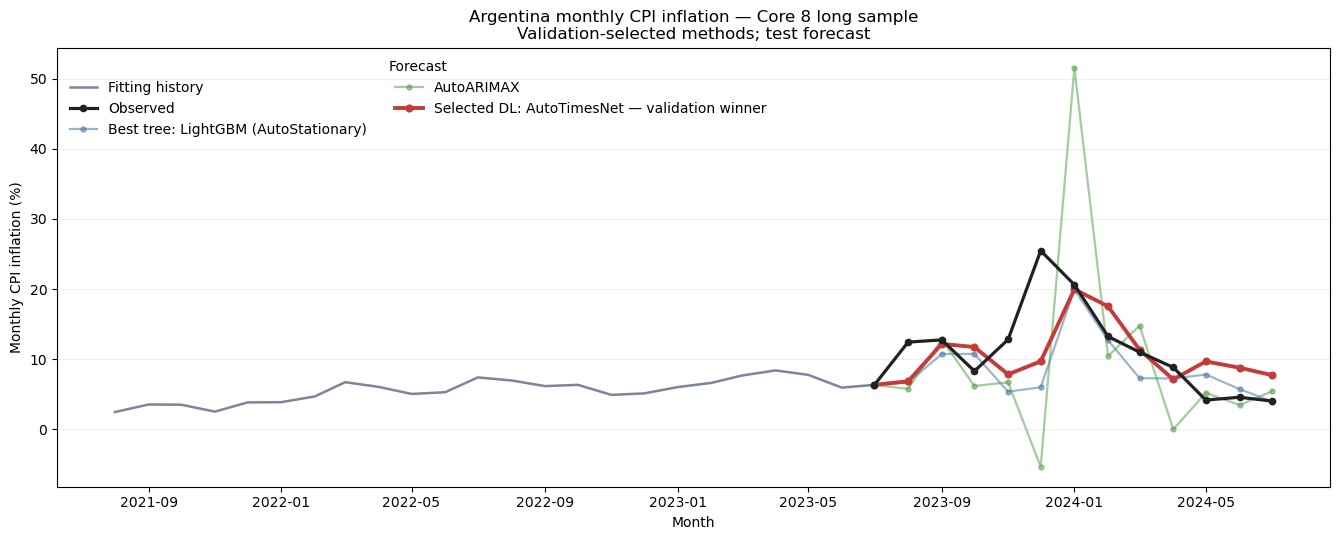

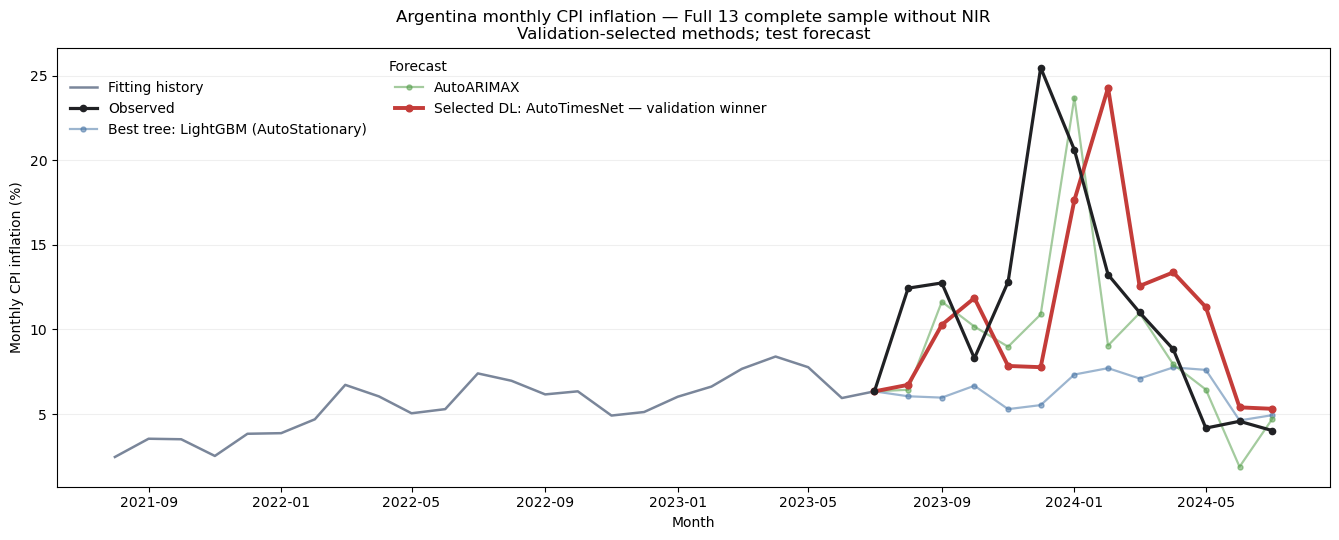

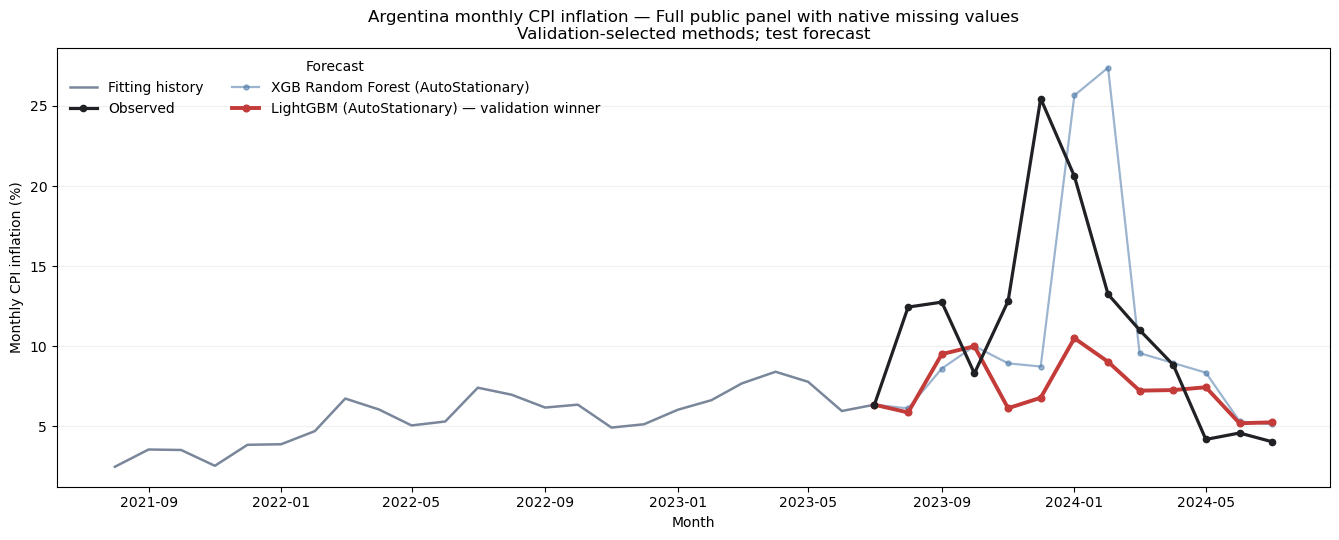

In [14]:
PLOT_HISTORY_STEPS = 24

for profile_name, data in all_results.items():
    history = data['fit_df'].tail(PLOT_HISTORY_STEPS)
    forecast = data['results']
    tree_selection = min(
        config_store['tree_winners'][profile_name].values(),
        key=lambda selection: selection['validation_mae'],
    )
    best_model_name = config_store['winners'][profile_name]['model']
    if FORTE_PROFILES[profile_name]['native_missing_only']:
        tree_candidates = [
            model if target == 'Original' else f'{model}_AutoStationary'
            for target in TREE_TARGET_TRANSFORMATIONS
            for model in TREE_MODELS
        ]
        selected_forecasts = [
            ('Tree model', model) for model in tree_candidates
            if model in forecast.columns
        ]
    else:
        selected_forecasts = [('Best tree', tree_selection['model'])]
        if 'AutoARIMAX' in forecast.columns:
            selected_forecasts.append(('AutoARIMAX', 'AutoARIMAX'))
        for dl_candidate in config_store.get('dl_shortlist', []):
            dl_model = dl_candidate['candidate_id']
            if (
                dl_candidate['profile'] == profile_name
                and dl_model in forecast.columns
            ):
                selected_forecasts.append(('Selected DL', dl_model))

    fig, axis = plt.subplots(figsize=(13.5, 5.5))
    axis.plot(
        history['date'], history['y'], color='#7A869A', linewidth=1.8,
        label='Fitting history',
    )
    observed_dates = pd.concat(
        [history['date'].tail(1), forecast['date']], ignore_index=True,
    )
    observed_values = pd.concat(
        [history['y'].tail(1), forecast['y']], ignore_index=True,
    )
    axis.plot(
        observed_dates, observed_values, color='#202124', linewidth=2.3,
        marker='o', markersize=4.5, label='Observed', zorder=5,
    )
    subdued_colors = ['#4C78A8', '#59A14F', '#B279A2', '#F28E2B']
    for model_index, (selection_label, model_name) in enumerate(selected_forecasts):
        model_dates = pd.concat(
            [history['date'].tail(1), forecast['date']], ignore_index=True,
        )
        model_values = pd.concat(
            [history['y'].tail(1), forecast[model_name]], ignore_index=True,
        )
        is_winner = model_name == best_model_name
        display_name = model_name.replace(
            '_AutoStationary', ' (AutoStationary)'
        ).replace('XGBRandomForest', 'XGB Random Forest')
        if selection_label not in {'Tree model', 'AutoARIMAX'}:
            display_name = f'{selection_label}: {display_name}'
        if is_winner:
            display_name = f'{display_name} — validation winner'
        axis.plot(
            model_dates, model_values,
            color=('#C43C39' if is_winner else subdued_colors[model_index]),
            linewidth=(2.8 if is_winner else 1.6),
            alpha=(1.0 if is_winner else 0.55),
            marker='o', markersize=(4.8 if is_winner else 3.6),
            label=display_name, zorder=(4 if is_winner else 2),
        )
    profile_label = FORTE_PROFILES[profile_name]['label']
    axis.set_title(
        f'Argentina monthly CPI inflation — {profile_label}\n'
        f'Validation-selected methods; {EVALUATION_SPLIT} forecast'
    )
    axis.set_xlabel('Month')
    axis.set_ylabel('Monthly CPI inflation (%)')
    axis.grid(axis='y', alpha=0.2)
    axis.legend(title='Forecast', frameon=False, ncol=2)
    fig.tight_layout()
    save_matplotlib_figure(
        fig,
        figure_path(
            'exogenous_models', 'argentina_inflation', profile_name,
            EVALUATION_SPLIT, extension=FIGURE_FORMAT,
        ),
        SAVE_FIGURES,
    )
    plt.show()

## Tree-model interpretation

The stored tree is the final monthly-origin fit and has seen the first eleven validation months. Intrinsic feature importance and partial dependence therefore use that final model's fitting history and remain secondary diagnostics; they are not applied retrospectively to earlier held-out rows. The final section uses rolling-origin TreeSHAP for the main local and global explanation.

In [15]:
if RUN_INTERPRETABILITY and EVALUATION_SPLIT == 'validation':
    import matplotlib.pyplot as plt
    from sklearn.inspection import PartialDependenceDisplay

    interpretation_rows = []
    for profile_name, trees in fitted_trees.items():
        tree_selection = config_store['best_tree'][profile_name]
        model_name = tree_selection['model']
        base_model = tree_selection['base_model']
        target_transformation = tree_selection['target_transformation']
        data = prepared_profiles[profile_name]
        eval_df = data['eval_df']
        interpretation_fit = pd.concat(
            [data['fit_df'], eval_df.iloc[:-1]], ignore_index=True
        )
        features = active_features(
            interpretation_fit, data['candidate_features']
        )
        feature_labels = [economic_feature_label(feature) for feature in features]
        model_config = config_store['tree'][
            data['config']['tuning_group']
        ][target_transformation][base_model]
        if model_name not in trees:
            print(f'{profile_name}: refitting one final-origin tree for interpretation')
            _, _, model = evaluate_tree_model(
                interpretation_fit,
                eval_df.iloc[[-1]],
                features,
                model_config,
                n_jobs=TREE_N_JOBS,
                weight_multipliers=QUALITY_WEIGHT_MULTIPLIERS,
                recalibrate_each_origin=True,
                feature_mode=FEATURE_MODE,
                freq='MS',
            )
            trees[model_name] = model
        else:
            model = trees[model_name]
        importance_values = np.asarray(model.feature_importances_, dtype=float)
        importance_total = importance_values.sum()
        if importance_total > 0:
            importance_values = importance_values / importance_total
        ranking = pd.DataFrame({
            'Profile': profile_name,
            'Model': model_name,
            'Target Transformation': target_transformation,
            'Feature': features,
            'Feature Label': feature_labels,
            'Importance': importance_values,
            'Importance Type': 'Final-origin intrinsic',
        }).sort_values('Importance', ascending=False)
        prepared_interpretation_fit, _, _ = prepare_tree_origin(
            interpretation_fit,
            eval_df.iloc[[-1]],
            features,
            target_transformation=target_transformation,
            freq=model_config.get('freq', 'MS'),
        )
        interpretation_rows.append(ranking)
        display(ranking.head(10))

        top_features = ranking.head(3)['Feature'].tolist()
        top_feature_indices = [features.index(feature) for feature in top_features]
        PartialDependenceDisplay.from_estimator(
            model,
            prepared_interpretation_fit[features],
            top_feature_indices,
            feature_names=feature_labels,
            kind='average',
        )
        plt.gcf().set_size_inches(15, 5.5)
        profile_label = FORTE_PROFILES[profile_name]['label']
        model_label = model_name.replace(
            '_AutoStationary', ' (AutoStationary)'
        ).replace('XGBRandomForest', 'XGB Random Forest')
        plt.suptitle(f'{profile_label}: {model_label} partial dependence')
        for axis in np.asarray(plt.gcf().axes, dtype=object).reshape(-1):
            axis.set_ylabel('AutoStationary model output')
        plt.tight_layout()
        save_matplotlib_figure(
            plt.gcf(),
            figure_path(
                'exogenous_models', 'argentina_inflation', profile_name,
                model_name, 'partial_dependence', extension=FIGURE_FORMAT,
            ),
            SAVE_FIGURES,
        )
        plt.show()

    interpretation_table = pd.concat(interpretation_rows, ignore_index=True)
    interpretation_table.to_csv(
        METRICS_DIR / f'exogenous_tree_importance_{EVALUATION_SPLIT}.csv',
        index=False,
    )

## Interpretation safeguards

Hyperparameter optimization cannot recognize that an economically impossible zero is actually missing; semantic recoding must precede every fold. Native NaN support likewise does not make the missingness ignorable, which is why explicit missingness and quality flags remain predictors. Optional quality weights are a tree-only sensitivity—not part of the primary equal-weight benchmark—and any multiplier must be declared before examining test errors.

## Rolling-origin TreeSHAP explanations

TreeSHAP is the primary variable explainer because the tree design is tabular one-step regression over explicit lag features. The validation-selected AutoStationary tree is independently refitted at each of the twelve expanding validation origins, and only that month's out-of-sample forecast row is explained. LightGBM uses an interventional background sampled deterministically from information available before each origin. XGBRandomForest uses XGBoost's exact native path-dependent TreeSHAP contributions; this also avoids the known incompatibility between older SHAP parsers and newer XGBoost vector-valued `base_score` metadata. The exported `Attribution Method` column records which calculation was used. Because inverse transformation is generally nonlinear, additive SHAP values reconstruct the tree output on the AutoStationary scale; the separately exported original-scale forecast is used for accuracy reporting. The global ranking is the mean absolute transformed-scale contribution across the twelve forecasts; mean signed contribution and positive-contribution share preserve direction and stability. For the main economic-driver table, signed contributions from a variable's lags, missingness indicator, and quality fields are first summed within each origin; absolute magnitude is calculated only after this grouping and then averaged.

Neither interventional nor path-dependent TreeSHAP resolves dependence among correlated macroeconomic predictors or identifies causal effects. SHAP magnitudes are importance measures on the fitted AutoStationary model-output scale, not percentage-point decompositions of the inverse-transformed inflation forecast. Test observations are never used as background or explanation data.

In [7]:
if RUN_SHAP and EVALUATION_SPLIT == 'validation':
    try:
        import shap
    except ImportError as exc:
        raise ImportError(
            'Install SHAP in this kernel environment with: '
            'conda install -n timeseriesforecasting -c conda-forge shap'
        ) from exc

    import matplotlib.pyplot as plt

    rolling_shap_rows = []
    for profile_name in ACTIVE_PROFILES:
        data = prepared_profiles[profile_name]
        group = data['config']['tuning_group']
        tree_selection = config_store['best_tree'][profile_name]
        model_name = tree_selection['base_model']
        target_transformation = tree_selection['target_transformation']
        features = data['candidate_features']
        config = config_store['tree'][group][target_transformation][model_name]
        shap_checkpoint = (
            EVALUATION_CHECKPOINT_DIR / f'tree_shap__{profile_name}.csv'
        )
        if REUSE_SHAP_CHECKPOINTS and shap_checkpoint.exists():
            print(f'{profile_name}: reusing checkpointed rolling TreeSHAP')
            attribution = pd.read_csv(shap_checkpoint, parse_dates=['Origin'])
        else:
            print(f'{profile_name}: computing rolling TreeSHAP')
            attribution = rolling_tree_shap(
                data['fit_df'],
                data['eval_df'],
                features,
                config,
                n_jobs=TREE_N_JOBS,
                weight_multipliers=QUALITY_WEIGHT_MULTIPLIERS,
                background_size=SHAP_BACKGROUND_SIZE,
            )
            attribution.to_csv(shap_checkpoint, index=False)
        attribution.insert(0, 'Profile', profile_name)
        rolling_shap_rows.append(attribution)

    rolling_shap_table = pd.concat(rolling_shap_rows, ignore_index=True)
    rolling_shap_summary = (
        rolling_shap_table
        .groupby(['Profile', 'Model', 'Target Transformation', 'Feature'], as_index=False)
        .agg(
            Mean_Absolute_SHAP=('Absolute SHAP', 'mean'),
            Mean_SHAP=('SHAP', 'mean'),
            SHAP_SD=('SHAP', 'std'),
            Positive_Share=('SHAP', lambda values: float((values > 0).mean())),
            Origins=('Origin', 'nunique'),
        )
        .sort_values(['Profile', 'Mean_Absolute_SHAP'], ascending=[True, False])
    )
    rolling_shap_summary['Importance Share'] = (
        rolling_shap_summary['Mean_Absolute_SHAP']
        / rolling_shap_summary.groupby('Profile')['Mean_Absolute_SHAP'].transform('sum')
    )
    rolling_shap_summary['Feature Label'] = rolling_shap_summary[
        'Feature'
    ].map(economic_feature_label)
    rolling_variable_by_origin = (
        rolling_shap_table
        .groupby(['Profile', 'Model', 'Target Transformation', 'Origin', 'Variable Group'], as_index=False)
        .agg(SHAP=('SHAP', 'sum'))
    )
    rolling_variable_by_origin['Absolute SHAP'] = rolling_variable_by_origin['SHAP'].abs()
    rolling_variable_summary = (
        rolling_variable_by_origin
        .groupby(['Profile', 'Model', 'Target Transformation', 'Variable Group'], as_index=False)
        .agg(
            Mean_Absolute_SHAP=('Absolute SHAP', 'mean'),
            Mean_SHAP=('SHAP', 'mean'),
            SHAP_SD=('SHAP', 'std'),
            Positive_Share=('SHAP', lambda values: float((values > 0).mean())),
            Origins=('Origin', 'nunique'),
        )
        .sort_values(['Profile', 'Mean_Absolute_SHAP'], ascending=[True, False])
    )
    rolling_variable_summary['Importance Share'] = (
        rolling_variable_summary['Mean_Absolute_SHAP']
        / rolling_variable_summary.groupby('Profile')['Mean_Absolute_SHAP'].transform('sum')
    )
    rolling_shap_table.to_csv(
        METRICS_DIR / 'exogenous_tree_shap_validation_by_origin.csv', index=False
    )
    rolling_shap_summary.to_csv(
        METRICS_DIR / 'exogenous_tree_shap_validation_summary.csv', index=False
    )
    rolling_variable_by_origin.to_csv(
        METRICS_DIR / 'exogenous_tree_shap_variable_by_origin.csv', index=False
    )
    rolling_variable_summary.to_csv(
        METRICS_DIR / 'exogenous_tree_shap_variable_summary.csv', index=False
    )

    for profile_name, profile_values in rolling_shap_table.groupby('Profile', sort=False):
        profile_label = FORTE_PROFILES[profile_name]['label']
        feature_summary = rolling_shap_summary.loc[
            rolling_shap_summary['Profile'].eq(profile_name)
        ].head(15)
        variable_summary = rolling_variable_summary.loc[
            rolling_variable_summary['Profile'].eq(profile_name)
        ]
        display(variable_summary)
        display(feature_summary)

        plot_summary = variable_summary.sort_values('Mean_Absolute_SHAP')
        plt.figure(figsize=(9, 6))
        plt.barh(plot_summary['Variable Group'], plot_summary['Mean_Absolute_SHAP'])
        plt.xlabel('Mean |SHAP| on AutoStationary model-output scale')
        plt.title(f'{profile_label}: rolling out-of-sample variable importance')
        plt.tight_layout()
        save_matplotlib_figure(
            plt.gcf(),
            figure_path(
                'exogenous_models', 'argentina_inflation', profile_name,
                'tree_shap_bar', extension=FIGURE_FORMAT,
            ),
            SAVE_FIGURES,
        )
        plt.show()

        feature_order = prepared_profiles[profile_name]['features']
        feature_labels = [economic_feature_label(feature) for feature in feature_order]
        value_matrix = profile_values.pivot(
            index='Origin', columns='Feature', values='SHAP'
        ).reindex(columns=feature_order)
        data_matrix = profile_values.pivot(
            index='Origin', columns='Feature', values='Feature Value'
        ).reindex(columns=feature_order)
        base_values = profile_values.groupby('Origin')['Baseline Forecast'].first()
        explanation = shap.Explanation(
            values=value_matrix.to_numpy(),
            base_values=base_values.reindex(value_matrix.index).to_numpy(),
            data=data_matrix.to_numpy(),
            feature_names=feature_labels,
        )
        shap.plots.beeswarm(explanation, max_display=15, show=False)
        plt.gcf().set_size_inches(11.5, 7)
        plt.title(f'{profile_label}: rolling TreeSHAP on AutoStationary scale')
        plt.tight_layout()
        save_matplotlib_figure(
            plt.gcf(),
            figure_path(
                'exogenous_models', 'argentina_inflation', profile_name,
                'tree_shap_beeswarm', extension=FIGURE_FORMAT,
            ),
            SAVE_FIGURES,
        )
        plt.show()

        final_month = value_matrix.index.max()
        final_explanation = explanation[list(value_matrix.index).index(final_month)]
        shap.plots.waterfall(final_explanation, max_display=15, show=False)
        plt.gcf().set_size_inches(11.5, 7)
        plt.title(f'{profile_label}: AutoStationary forecast for {final_month:%Y-%m}')
        plt.tight_layout()
        save_matplotlib_figure(
            plt.gcf(),
            figure_path(
                'exogenous_models', 'argentina_inflation', profile_name,
                'tree_shap_waterfall', extension=FIGURE_FORMAT,
            ),
            SAVE_FIGURES,
        )
        plt.show()

core8_long: computing rolling TreeSHAP


KeyboardInterrupt: 

## Rolling one-step ShapTime for the selected deep model

For each complete-data profile, the DL architecture with the lowest external-validation MAE is selected without reference to test. The original Optuna trial stored its prediction path and configuration but not its trained weights. Consequently, this diagnostic reconstructs a new seed-67 fit of the frozen configuration at the start of the validation block; it does not claim to explain the discarded trial weights. At each of the twelve rolling one-step origins, the expanding autoregressive input window is divided into four contiguous super-times and compared with the seasonally aligned window from twelve months earlier. Exact group Shapley values are computed before that origin's outcome is revealed. The refitted model weights and the origin's one-row future-exogenous input remain fixed across coalitions.

This is a rolling one-step adaptation of ShapTime's super-time principle rather than the authors' notebook code, which is not distributed as an installable package. The full-coalition refit forecast is compared with the stored validation path at every origin, and their maximum absolute difference is exported. This difference must be considered when interpreting the temporal attribution because same-seed CUDA training is not necessarily bitwise reproducible. Mean absolute ShapTime measures which portions of the target-history window the selected-configuration refit relies upon; signed values show whether a window raises or lowers an origin's refit forecast relative to the seasonal background. It does **not** rank macroeconomic variables or explain the exact stored trial when the paths differ. Rolling TreeSHAP above remains the primary variable-driver analysis. Neural attribution runs in an isolated worker process to prevent the incompatible OpenMP runtimes used by PyTorch and the notebook's tree-explanation stack from terminating the kernel.

core8_long: rolling h=1 ShapTime for AutoTimesNet
[ShapTime worker] AutoTimesNet: fitting one h=1 model and explaining 12 rolling origins
[ShapTime worker] Seed set to 67
[ShapTime worker] ShapTime origin 1/12 complete
[ShapTime worker] ShapTime origin 2/12 complete
[ShapTime worker] ShapTime origin 3/12 complete
[ShapTime worker] ShapTime origin 4/12 complete
[ShapTime worker] ShapTime origin 5/12 complete
[ShapTime worker] ShapTime origin 6/12 complete
[ShapTime worker] ShapTime origin 7/12 complete
[ShapTime worker] ShapTime origin 8/12 complete
[ShapTime worker] ShapTime origin 9/12 complete
[ShapTime worker] ShapTime origin 10/12 complete
[ShapTime worker] ShapTime origin 11/12 complete
[ShapTime worker] ShapTime origin 12/12 complete
[ShapTime worker] saved 48 origin-window attributions to C:\Users\tutol\Desktop\Repos\Modern-Time-Series-Forecasting-with-Python-2E\thesis\metrics\exogenous_checkpoints\validation_rolling_h1_refit_shaptime_v3\dl_shaptime_rolling_h1__core8_long__AutoT

,Profile,Model,Super Time,Window,Oldest Lag,Newest Lag,Mean_Absolute_ShapTime,Mean_ShapTime,ShapTime_SD,Positive_Share,Origins,Refit_Max_Absolute_Difference,Exact_Stored_Path,Importance Share
0,core8_long,AutoTimesNet,1,t-24:t-19,24,19,0.628478,-0.432684,0.836001,0.500000,12,2.236986,False,0.164829
1,core8_long,AutoTimesNet,2,t-18:t-13,18,13,0.312201,0.010126,0.385139,0.666667,12,2.236986,False,0.081880
2,core8_long,AutoTimesNet,3,t-12:t-7,12,7,0.861596,0.798472,0.848239,0.916667,12,2.236986,False,0.225969
3,core8_long,AutoTimesNet,4,t-6:t-1,6,1,2.010625,2.010625,0.763098,1.000000,12,2.236986,False,0.527322


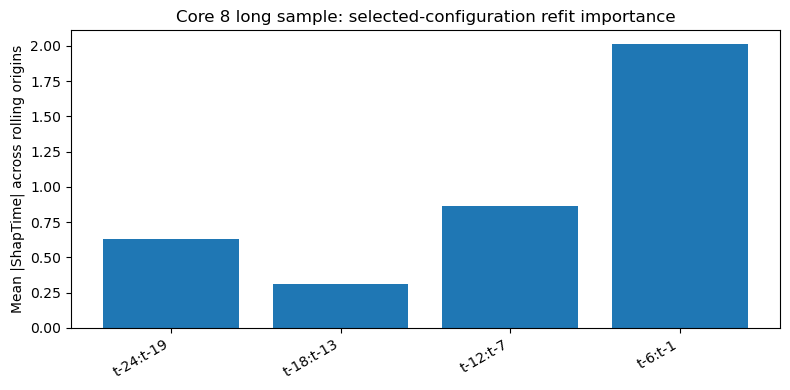

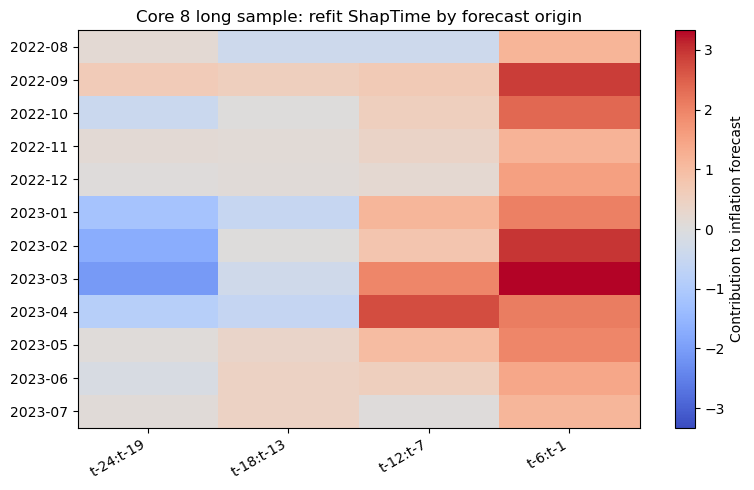

,Profile,Model,Super Time,Window,Oldest Lag,Newest Lag,Mean_Absolute_ShapTime,Mean_ShapTime,ShapTime_SD,Positive_Share,Origins,Refit_Max_Absolute_Difference,Exact_Stored_Path,Importance Share
4,full13_complete_no_nir,AutoTimesNet,1,t-12:t-10,12,10,0.370263,-0.353017,0.314066,0.083333,12,1.184896,False,0.109332
5,full13_complete_no_nir,AutoTimesNet,2,t-9:t-7,9,7,0.619066,0.110557,0.948509,0.500000,12,1.184896,False,0.182799
6,full13_complete_no_nir,AutoTimesNet,3,t-6:t-4,6,4,0.383371,-0.018336,0.536427,0.500000,12,1.184896,False,0.113202
7,full13_complete_no_nir,AutoTimesNet,4,t-3:t-1,3,1,2.013898,2.013898,0.863941,1.000000,12,1.184896,False,0.594667


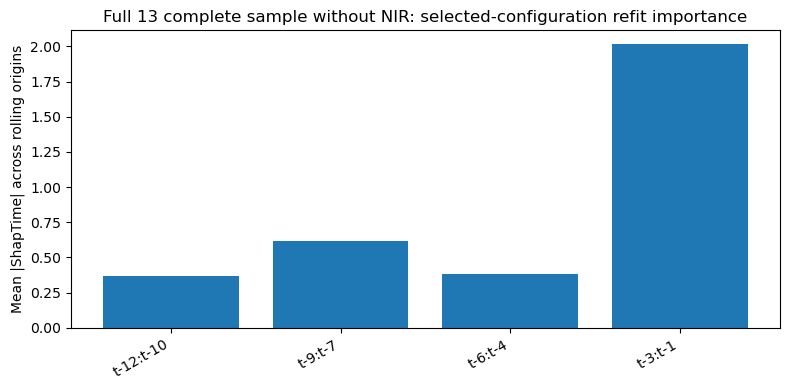

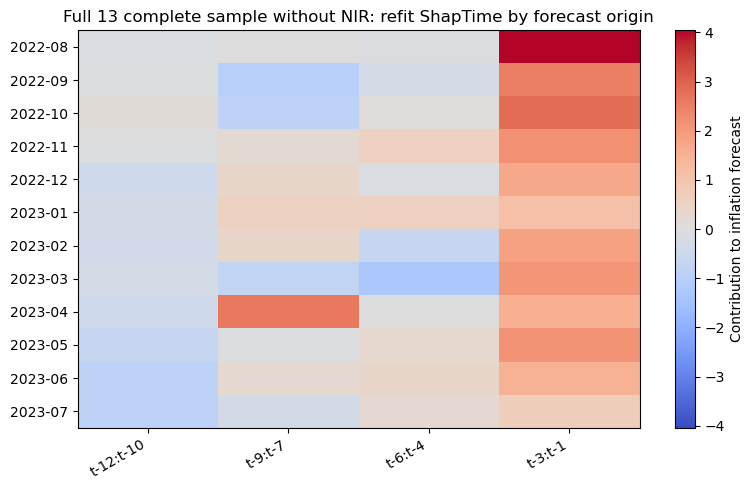

In [1]:
# Restart-safe: this cell reloads the frozen validation selections and
# prediction checkpoints instead of depending on earlier notebook variables.
from pathlib import Path
import hashlib
import importlib
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'thesis').exists():
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)
THESIS_DIR = REPO_ROOT / 'thesis'
if str(THESIS_DIR) not in sys.path:
    sys.path.insert(0, str(THESIS_DIR))

import exogenous_evaluation
importlib.reload(exogenous_evaluation)
from exogenous_evaluation import (
    FORTE_PROFILES,
    active_features,
    build_forte_profile,
    fit_and_eval_frames,
    run_rolling_dl_shaptime_subprocess,
    split_forte_profile,
)
from reporting import figure_path, save_matplotlib_figure

FEATURE_MODE = globals().get('FEATURE_MODE', 'strict_lagged')
DL_PROTOCOL = 'rolling_h1_fixed_weights'
VALIDATION_SIZE = globals().get('VALIDATION_SIZE', 12)
TEST_SIZE = globals().get('TEST_SIZE', 12)
SHAPTIME_SUPER_TIMES = globals().get('SHAPTIME_SUPER_TIMES', 4)
SHAPTIME_SEASONAL_BACKGROUND_LAG = globals().get(
    'SHAPTIME_SEASONAL_BACKGROUND_LAG', 12,
)
SAVE_FIGURES = globals().get('SAVE_FIGURES', True)
FIGURE_FORMAT = globals().get('FIGURE_FORMAT', 'jpg')
RUN_DL_SHAPTIME = globals().get('RUN_DL_SHAPTIME', True)
CONFIG_PATH = (
    THESIS_DIR / 'model_configs' / 'exogenous_validation_configs.json'
)
METRICS_DIR = THESIS_DIR / 'metrics'
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f'Frozen validation selection not found: {CONFIG_PATH}')
config_store = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))
ACTIVE_PROFILES = list(config_store.get('best_dl', {}))
if not ACTIVE_PROFILES:
    raise ValueError('No frozen neural validation winners were found')
SHAPTIME_CHECKPOINT_DIR = (
    METRICS_DIR / 'exogenous_checkpoints'
    / 'validation_rolling_h1_refit_shaptime_v3'
)
SHAPTIME_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

if RUN_DL_SHAPTIME:

    shaptime_rows = []
    for profile_name, selection in config_store['best_dl'].items():
        if profile_name not in ACTIVE_PROFILES:
            continue
        frame, profile_config = build_forte_profile(
            profile_name, feature_mode=FEATURE_MODE,
        )
        splits = split_forte_profile(frame, VALIDATION_SIZE, TEST_SIZE)
        fit_df, eval_df = fit_and_eval_frames(splits, 'validation')
        frozen_features = active_features(
            fit_df, profile_config['feature_columns'],
        )
        model_name = selection['architecture']
        selection_name = selection['model']
        print(f'{profile_name}: rolling h=1 ShapTime for {selection_name}')
        config_hash = hashlib.sha256(
            json.dumps(
                selection['resolved_config'], sort_keys=True, default=str,
            ).encode()
        ).hexdigest()
        shortlist_record = next(
            record for record in config_store['dl_shortlist']
            if record['profile'] == profile_name
            and record['candidate_id'] == selection_name
        )
        if (
            shortlist_record.get('metric', {}).get('DL Protocol')
            != 'rolling_h1_fixed_weights'
            or int(shortlist_record.get('metric', {}).get('Fits', -1)) != 1
        ):
            raise ValueError(
                f'{profile_name}: selected record is not a one-fit rolling h=1 run'
            )
        saved = shortlist_record['results']
        stored_frame = pd.DataFrame({
            'date': pd.to_datetime(saved['date']),
            'y': np.asarray(saved['y'], dtype=float),
            selection_name: np.asarray(saved['prediction'], dtype=float),
        })
        if len(stored_frame) != 12 or stored_frame['date'].nunique() != 12:
            raise ValueError(
                f'{profile_name}: frozen selection does not store 12 origins'
            )
        if not stored_frame['date'].equals(
            eval_df['date'].reset_index(drop=True)
        ):
            raise ValueError(f'{profile_name}: saved validation dates changed')
        if not np.allclose(
            stored_frame['y'].astype(float), eval_df['y'].astype(float),
            rtol=0.0, atol=1e-12,
        ):
            raise ValueError(f'{profile_name}: saved validation targets changed')
        stored_predictions = stored_frame[selection_name].astype(float).to_numpy()
        prediction_hash = hashlib.sha256(
            stored_predictions.astype('<f8').tobytes()
        ).hexdigest()
        prediction_export = stored_frame.copy()
        prediction_export.insert(0, 'Profile', profile_name)
        prediction_export['DL Protocol'] = DL_PROTOCOL
        prediction_export['Selection Trial Number'] = int(
            shortlist_record['trial_number']
        )
        prediction_export['Selection Config Hash'] = config_hash
        prediction_export['Stored Prediction Hash'] = prediction_hash
        prediction_export.to_csv(
            SHAPTIME_CHECKPOINT_DIR
            / f'frozen_validation_predictions__{profile_name}__{model_name}.csv',
            index=False,
        )
        shaptime_checkpoint = (
            SHAPTIME_CHECKPOINT_DIR
            / f'dl_shaptime_rolling_h1__{profile_name}__{model_name}.csv'
        )
        attribution = None
        if shaptime_checkpoint.exists():
            candidate = pd.read_csv(shaptime_checkpoint)
            compatible = (
                {
                    'ShapTime Protocol', 'DL Protocol',
                    'Selection Config Hash', 'Stored Prediction Hash',
                    'Origin', 'Horizon', 'Fits', 'Future Rows',
                    'Attribution Basis', 'Stored Forecast Match',
                    'Stored Forecast Max Abs Difference',
                }.issubset(candidate.columns)
                and set(candidate['ShapTime Protocol'])
                == {'rolling_h1_fixed_weights_refit_shaptime_v3'}
                and set(candidate['DL Protocol']) == {DL_PROTOCOL}
                and set(candidate['Selection Config Hash']) == {config_hash}
                and set(candidate['Stored Prediction Hash']) == {prediction_hash}
                and candidate['Origin'].nunique() == 12
                and set(candidate['Horizon']) == {1}
                and set(candidate['Fits']) == {1}
                and set(candidate['Future Rows']) == {1}
            )
            if compatible:
                candidate['Origin'] = pd.to_datetime(candidate['Origin'])
                candidate['Information Cutoff'] = pd.to_datetime(
                    candidate['Information Cutoff']
                )
                attribution = candidate
                print(f'{profile_name}: reusing compatible rolling ShapTime')
            else:
                print(f'{profile_name}: ignoring incompatible ShapTime checkpoint')
        if attribution is None:
            attribution = run_rolling_dl_shaptime_subprocess(
                fit_df,
                eval_df,
                frozen_features,
                model_name,
                selection['resolved_config'],
                expected_predictions=stored_predictions,
                output_path=shaptime_checkpoint,
                feature_mode=FEATURE_MODE,
                n_super_times=SHAPTIME_SUPER_TIMES,
                seasonal_background_lag=SHAPTIME_SEASONAL_BACKGROUND_LAG,
                require_prediction_match=False,
            )
            attribution['Selection'] = selection_name
            attribution['Selection Trial Number'] = int(
                shortlist_record['trial_number']
            )
            attribution['Stored Prediction Source'] = str(CONFIG_PATH)
            attribution['Selection Config Hash'] = config_hash
            attribution['Stored Prediction Hash'] = prediction_hash
            attribution.to_csv(shaptime_checkpoint, index=False)
        refit_difference = float(
            attribution['Stored Forecast Max Abs Difference'].max()
        )
        if not bool(attribution['Stored Forecast Match'].all()):
            print(
                f'{profile_name}: original weights were not saved; temporal '
                f'attribution describes a seed-67 refit (maximum difference '
                f'from stored forecasts: {refit_difference:.4f}).'
            )
        attribution.insert(0, 'Profile', profile_name)
        shaptime_rows.append(attribution)

    rolling_shaptime_table = pd.concat(shaptime_rows, ignore_index=True)
    rolling_shaptime_summary = (
        rolling_shaptime_table
        .groupby(
            ['Profile', 'Model', 'Super Time', 'Window', 'Oldest Lag', 'Newest Lag'],
            as_index=False,
        )
        .agg(
            Mean_Absolute_ShapTime=('Absolute ShapTime', 'mean'),
            Mean_ShapTime=('ShapTime', 'mean'),
            ShapTime_SD=('ShapTime', 'std'),
            Positive_Share=('ShapTime', lambda values: float((values > 0).mean())),
            Origins=('Origin', 'nunique'),
            Refit_Max_Absolute_Difference=(
                'Stored Forecast Max Abs Difference', 'max',
            ),
            Exact_Stored_Path=('Stored Forecast Match', 'all'),
        )
        .sort_values(
            ['Profile', 'Mean_Absolute_ShapTime'], ascending=[True, False]
        )
    )
    rolling_shaptime_summary['Importance Share'] = (
        rolling_shaptime_summary['Mean_Absolute_ShapTime']
        / rolling_shaptime_summary.groupby('Profile')[
            'Mean_Absolute_ShapTime'
        ].transform('sum')
    )
    rolling_shaptime_table.to_csv(
        METRICS_DIR / 'exogenous_dl_shaptime_rolling_h1_refit_validation_by_origin.csv',
        index=False,
    )
    rolling_shaptime_summary.to_csv(
        METRICS_DIR / 'exogenous_dl_shaptime_rolling_h1_refit_validation_summary.csv',
        index=False,
    )

    for profile_name, profile_values in rolling_shaptime_table.groupby(
        'Profile', sort=False
    ):
        profile_label = FORTE_PROFILES[profile_name]['label']
        summary = rolling_shaptime_summary.loc[
            rolling_shaptime_summary['Profile'].eq(profile_name)
        ].sort_values('Oldest Lag', ascending=False)
        display(summary)

        plt.figure(figsize=(8, 4))
        plt.bar(
            summary['Window'], summary['Mean_Absolute_ShapTime']
        )
        plt.ylabel('Mean |ShapTime| across rolling origins')
        plt.title(f'{profile_label}: selected-configuration refit importance')
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        save_matplotlib_figure(
            plt.gcf(),
            figure_path(
                'exogenous_models', 'argentina_inflation', profile_name,
                'shaptime_rolling_h1_refit_bar', extension=FIGURE_FORMAT,
            ),
            SAVE_FIGURES,
        )
        plt.show()

        heatmap = profile_values.pivot(
            index='Origin', columns='Window', values='ShapTime'
        ).reindex(columns=summary['Window'])
        limit = float(np.nanmax(np.abs(heatmap.to_numpy())))
        fig, ax = plt.subplots(figsize=(8, 5))
        image = ax.imshow(
            heatmap.to_numpy(), aspect='auto', cmap='coolwarm',
            vmin=-limit, vmax=limit,
        )
        ax.set_xticks(range(len(heatmap.columns)), heatmap.columns, rotation=30, ha='right')
        ax.set_yticks(
            range(len(heatmap.index)),
            [date.strftime('%Y-%m') for date in heatmap.index],
        )
        ax.set_title(f'{profile_label}: refit ShapTime by forecast origin')
        fig.colorbar(image, ax=ax, label='Contribution to inflation forecast')
        fig.tight_layout()
        save_matplotlib_figure(
            fig,
            figure_path(
                'exogenous_models', 'argentina_inflation', profile_name,
                'shaptime_rolling_h1_refit_heatmap', extension=FIGURE_FORMAT,
            ),
            SAVE_FIGURES,
        )
        plt.show()